In [1]:
import numpy as np 
import pandas as pd 
from pathlib import Path
import pickle 
import pprint

import IPython.display as ipd

from corpus.swc_popham_test_h5 import SWCPophamCondTestSet2024

# In this notebook

Check audio stimuli generated for model experiment

Stimuli saved as h5 files create stimuli using `src/get_swc_popham_expmt_stim_2024_for_model.py` 

Stimuli live at `/om/user/imgriff/datasets/human_swc_popham_exmpt_2024/model_eval_h5s`



___

## Set experiment out path

In [2]:
expmnt_dir = Path('/om/user/imgriff/datasets/human_swc_popham_exmpt_2024/model_eval_h5s')


#### Init dataset 


In [3]:
harmonic_dataset = SWCPophamCondTestSet2024(expmnt_dir, target_harmonicity='harmonic', distractor_harmonicity='harmonic')

In [4]:
cue, target, harm_distractor, word_int, sex_cond, df_row = harmonic_dataset[1]

In [5]:
## listen to cue, target, and distractor 
print("Cue")
ipd.display(ipd.Audio(cue, rate=44100))
print("Target")
ipd.display(ipd.Audio(target, rate=44100))
print("Distractor")
ipd.display(ipd.Audio(harm_distractor, rate=44100))


Cue


Target


Distractor


## Listen to inharmonic stimuli

In [6]:
inharmonic_dataset = SWCPophamCondTestSet2024(expmnt_dir, target_harmonicity='inharmonic', distractor_harmonicity='inharmonic')
cue, target, distractor, word_int, sex_cond, df_row = inharmonic_dataset[1]

## listen to cue, target, and distractor 
print("Cue")
ipd.display(ipd.Audio(cue, rate=44100))
print("Target")
ipd.display(ipd.Audio(target, rate=44100))
print("Distractor")
ipd.display(ipd.Audio(distractor, rate=44100))


Cue


Target


Distractor


## Listen to whispered stimuli

In [7]:
whispered_dataset = SWCPophamCondTestSet2024(expmnt_dir, target_harmonicity='whispered', distractor_harmonicity='whispered')
cue, target, distractor, word_int, sex_cond, df_row = whispered_dataset[1]

## listen to cue, target, and distractor 
print("Cue")
ipd.display(ipd.Audio(cue, rate=44100))
print("Target")
ipd.display(ipd.Audio(target, rate=44100))
print("Distractor")
ipd.display(ipd.Audio(distractor, rate=44100))


Cue


Target


Distractor


/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "
/tmp/ipykernel_3315270/3408578239.py:6: RuntimeWarning: divide by zero encountered in log10
  plt.pcolormesh(t, f, 10*np.log10(Sxx))
/tmp/ipykernel_3315270/3408578239.py:13: RuntimeWarning: divide by zero encountered in log10
  plt.pcolormesh(t, f, 10*np.log10(Sxx))


Text(0.5, 1.0, 'Inharmonic Distractor')

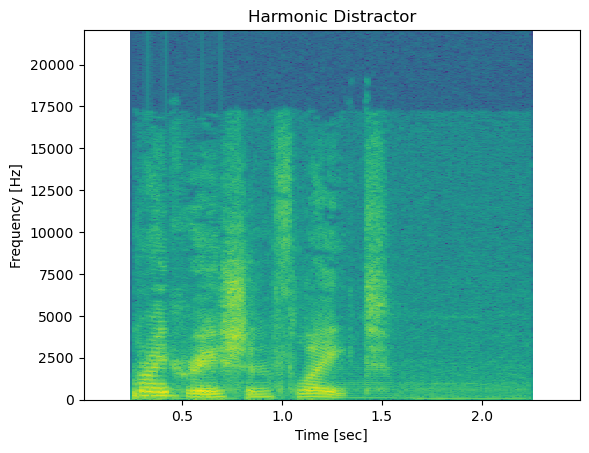

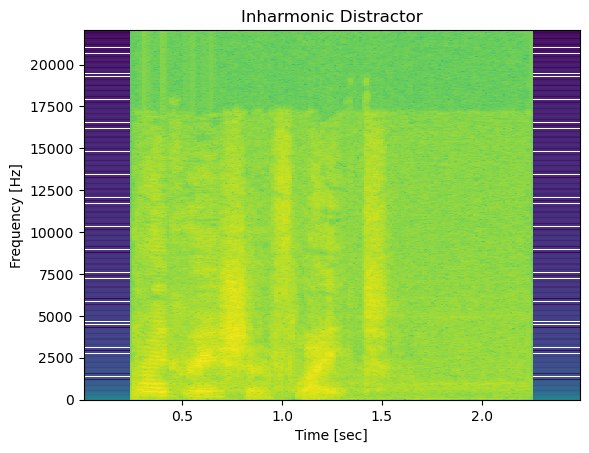

In [8]:
### Check spectral overlap between harm_distractor and distractor
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

f, t, Sxx = spectrogram(harm_distractor, fs=44100, nperseg=1024, noverlap=512, nfft=2048)
plt.pcolormesh(t, f, 10*np.log10(Sxx))
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.title('Harmonic Distractor')

f, t, Sxx = spectrogram(distractor, fs=44100, nperseg=1024, noverlap=512, nfft=2048)
plt.figure()
plt.pcolormesh(t, f, 10*np.log10(Sxx))
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.title('Inharmonic Distractor')


In [9]:
### Not distractor test 

harmonic_dataset = SWCPophamCondTestSet2024(expmnt_dir, target_harmonicity='harmonic', distractor_harmonicity=None)

In [10]:
df = {1:{'target_harmonicity': 'harmonic', 'distractor_harmonicity': None}}

In [11]:
params = df[1]

In [12]:
no_dist_df = SWCPophamCondTestSet2024(expmnt_dir, **params)
cue, target, distractor, word_int, sex_cond, df_row = no_dist_df[1]

## listen to cue, target, and distractor 
print("Cue")
ipd.display(ipd.Audio(cue, rate=44100))
print("Target")
ipd.display(ipd.Audio(target, rate=44100))
print("Distractor")
ipd.display(ipd.Audio(distractor, rate=44100))

Cue


Target


Distractor


ValueError: No audio data found. Expecting filename, url, or data.